# 🌡️ A small energy model under a global-warming scenario (PECD 4.2)

This notebook builds and runs a **small electricity dispatch model** whose wind, solar and
hydro inputs come from a **CMIP6 climate-projection scenario** of the Pan-European Climate
Database (PECD 4.2). You choose the scenario (climate model + emission pathway + future year)
and the launch assumptions; the **first run downloads** the matching PECD set from the
Copernicus CDS, then we process it and feed it into a `pommes_craft` model.

Flow: **scenario choices → first-run download (CDS) → process to capacity factors + hydro
inflow → build a small `pommes_craft` model → solve → read off the dispatch.**

> Long-term plan: cache the (heavy) CDS downloads once to a Google Cloud bucket and pull from
> there on subsequent runs — see the last section. For now the first run hits CDS directly.

## 1. Prerequisites

```bash
pip install supplyforge pommes_craft          # + an LP solver, e.g. HiGHS
```

PECD downloads need a **Copernicus CDS** account + API key in `~/.cdsapirc` (or
`CDSAPI_URL`/`CDSAPI_KEY` in `.env`), and a **one-time Terms-&-Conditions** acceptance on the
[`sis-energy-pecd`](https://cds.climate.copernicus.eu/datasets/sis-energy-pecd) dataset page.

⚠️ **First run is heavy**: each PECD variable is a separate CDS request (~8 min when the queue
is busy). This notebook fetches **4** products (solar, onshore wind, offshore wind, reservoir
inflow) for the one chosen climate year, then **caches** them under `results/pecd_study/`
(re-runs skip the download).

## 2. Choose the climate scenario

Everything below maps to PECD CDS request fields. Swap any value and re-run to compare scenarios.

In [2]:
# Embed figures inline (robust to any MPLBACKEND in the env).
%matplotlib inline
SCENARIO = {
    "country": "FR",            # ISO-2 code (DE, ES, IT, NO, GR, ...)
    "model_year": 2050,         # the operational year simulated by the model

    # --- the global-warming knobs -------------------------------------------------
    "temporal_period": "future_projections",   # "future_projections" | "historical"
    "climate_model":   "ec_earth3",            # CMIP6 model (= PECD `origin`). Options:
                                               #   cmcc_cm2_sr5 | ec_earth3 | mpi_esm1_2_hr
                                               #   awi_cm_1_1_mr | bcc_csm2_mr | mri_esm2_0
    "ssp":             "ssp5_8_5",             # emission pathway: ssp1_2_6 | ssp2_4_5 | ssp3_7_0 | ssp5_8_5
    "year":            2050,                    # climate/weather year, 2015–2100 for projections

    # For a quick, already-validated baseline instead of a projection, use:
    #   "temporal_period": "historical", "climate_model": "era5_reanalysis",
    #   "ssp": None, "year": 2008   (and any past year 1950–near-present)
}
print(f"Scenario: {SCENARIO['country']} | {SCENARIO['climate_model']} / {SCENARIO['ssp']} "
      f"| climate year {SCENARIO['year']} | model year {SCENARIO['model_year']}")

Scenario: FR | ec_earth3 / ssp5_8_5 | climate year 2050 | model year 2050


## 3. Launch assumptions (what *you* decide)

PECD provides **weather only** — the *capacity factors* and *hydro inflow shape*. For a future
year there is no observed fleet or demand, so the **installed capacities, demand level and
storage sizing are scenario assumptions you set here** (in GW / TWh / GWh). Edit freely.

In [3]:
ASSUMPTIONS = {
    # Installed fleet for the model year (GW)
    "solar_GW":          100.0,
    "wind_onshore_GW":    70.0,
    "wind_offshore_GW":   30.0,
    "hydro_turbine_GW":   20.0,   # reservoir-hydro turbine power
    "hydro_energy_GWh":  30000.0, # reservoir energy capacity (≈ ERAA Storage.xlsx if you have it)
    "gas_GW":             40.0,   # dispatchable backup, built up to this as needed

    # Economics / demand
    "gas_cost":           80.0,   # €/MWh variable cost of the gas backup
    "demand_TWh":        500.0,   # annual electricity demand (flat profile here; see notes for demandforge)
}
print("Assumptions:", ASSUMPTIONS)

Assumptions: {'solar_GW': 100.0, 'wind_onshore_GW': 70.0, 'wind_offshore_GW': 30.0, 'hydro_turbine_GW': 20.0, 'hydro_energy_GWh': 30000.0, 'gas_GW': 40.0, 'gas_cost': 80.0, 'demand_TWh': 500.0}


## 4. First run — download the PECD set for this scenario

This builds the supplyforge config from `SCENARIO` and calls the PECD fetcher. On first run it
downloads from CDS (cached afterwards). Offshore/onshore wind use the ERAA-2026 zones
(`p2on`/`p2of`) for projections, ERAA-2025 (`peon`/`peof`) for the historical stream.

In [4]:
# Stream CDS download progress in the notebook. cdsapi reports via the logging
# module; force=True is required because basicConfig is a no-op once Jupyter has
# configured logging, so without it the INFO/progress lines never reach the cell.
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s", force=True)

from supplyforge.fetch.pecd.study import fetch_pecd_data

_is_proj = SCENARIO["temporal_period"] == "future_projections"
config = {
    "res_source": "pecd",
    "hydro_source": "pecd",
    "pecd": {
        "pecd_version": "pecd4_2",
        "temporal_period": SCENARIO["temporal_period"],
        "origin": SCENARIO["climate_model"],
        "emission_scenario": SCENARIO["ssp"] if _is_proj else None,
        "file_version": "fv1",
        "spatial_resolution_wind": "p2on" if _is_proj else "peon",
        "spatial_resolution_solar": "szon",
        "wind_technology_onshore": "30",
        "wind_technology_offshore": "20",
        "energy_scenario": "resource_grade_b",
        "climate_years": [SCENARIO["year"]],
        "variables_hydro": ["hydropower_reservoir_inflow"],  # reservoir inflow only (no RoR in this small model)
        "ror_source": "entsoe",                              # -> fetch SPV/WON/WOF/HRI only (4 products)
    },
}

# First run downloads ~4 products from CDS (~8 min each); subsequent runs use the cache.
fetch_pecd_data(config)
print("PECD set staged under results/pecd_study/")

2026-06-12 15:59:30,949 | INFO | NumExpr defaulting to 8 threads.
2026-06-12 15:59:31,260 | INFO | PECD: fetching codes ['SPV', 'WON', 'WOF', 'HRI'] for climate years [2050]
2026-06-12 15:59:31,875 INFO [2026-06-11T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 15 June. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure-part-2/150414).
2026-06-12 15:59:31,875 | INFO | [2026-06-11T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 15 June. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure-part-2/150414).
2026-06-12 15:59:31,877 | INFO | PECD: pecd42_SPV_szon_2050_ec_earth3_ssp5_8_5_fv1.csv already staged, skippin

PECD set staged under results/pecd_study/


## 5. Process PECD → national capacity factors + reservoir inflow

We aggregate the per-zone PECD data to the country (null-aware: empty placeholder zones are
dropped) and turn the weekly reservoir-inflow energy into an hourly MW profile.

In [4]:
import numpy as np
import pandas as pd
from supplyforge.process.pecd.capacity_factor import national_cf_from_frame
from supplyforge.process.pecd.hydro_inflow import pecd_reservoir_inflow, find_pecd_csv

country, year = SCENARIO["country"], SCENARIO["year"]

def _read(code):
    p = find_pecd_csv(code, year)
    return pd.read_csv(p, comment="#", index_col="Date") if p else None

cf = {}
for code, label in [("SPV", "Solar"), ("WON", "Wind Onshore"), ("WOF", "Wind Offshore")]:
    df = _read(code)
    vals = national_cf_from_frame(code, country, df, config) if df is not None else None
    if vals is not None:
        cf[label] = vals

hri = _read("HRI")
inflow_mw = pecd_reservoir_inflow(hri, country, year)["inflow_MW"].to_numpy() if hri is not None else np.zeros(8760)

print("Annual-mean capacity factor (the climate signal):",
      {k: round(float(np.nanmean(v)), 3) for k, v in cf.items()})
print(f"Reservoir inflow: mean {np.nanmean(inflow_mw):.0f} MW, peak {np.nanmax(inflow_mw):.0f} MW")

# A pre-solve sanity check you can read without a solver:
pot = sum(np.nansum(cf[l]) * ASSUMPTIONS[k] * 1000.0 for l, k in
          [("Solar", "solar_GW"), ("Wind Onshore", "wind_onshore_GW"), ("Wind Offshore", "wind_offshore_GW")]
          if l in cf) / 1e6
print(f"Potential renewable generation ≈ {pot:,.0f} TWh/yr  vs  demand {ASSUMPTIONS['demand_TWh']:,.0f} TWh/yr")

2026-06-07 18:07:20,556 | INFO | PECD: multiple SPV files for 2050: ['pecd42_SPV_nuts_2_2050_ec_earth3_ssp5_8_5_fv1.csv', 'pecd42_SPV_szon_2050_ec_earth3_ssp5_8_5_fv1.csv']; using pecd42_SPV_nuts_2_2050_ec_earth3_ssp5_8_5_fv1.csv.


2026-06-07 18:07:20,900 | INFO | PECD: country 'FR' -> zones ['FR10', 'FRB0', 'FRC1', 'FRC2', 'FRD1', 'FRD2', 'FRE1', 'FRE2', 'FRF1', 'FRF2', 'FRF3', 'FRG0', 'FRH0', 'FRI1', 'FRI2', 'FRI3', 'FRJ1', 'FRJ2', 'FRK1', 'FRK2', 'FRL0', 'FRM0']


2026-06-07 18:07:20,900 | WARNING | PECD weights: no per-zone installed capacities configured for solar; multi-zone aggregation will use EQUAL weights (less precise). Set pecd.zone_capacities or pecd.zone_capacities_csv for precise weighting. Run write_capacity_template(country, level, path) to emit a per-zone CSV skeleton (from the zone registry), fill it with installed MW from your PEMMDB/ERAA scenario, and point pecd.zone_capacities_csv at it.


2026-06-07 18:07:20,976 | WARNING | PECD: no per-zone installed capacities available for 'FR'; aggregating 22 zone(s) with EQUAL weights (less precise).


2026-06-07 18:07:21,098 | INFO | PECD: country 'FR' -> zones ['FR01', 'FR02', 'FR03', 'FR04', 'FR05', 'FR07', 'FR08', 'FR09', 'FR10', 'FR11', 'FR12', 'FR13', 'FR14', 'FR15', 'FR16', 'FR17', 'FR18', 'FR19', 'FR20', 'FR21', 'FR22', 'FR23', 'FR24', 'FR25', 'FR26', 'FR27']


...

2026-06-07 18:07:21,146 | INFO | PECD: country 'FR' -> zones ['FR00']


2026-06-07 18:07:21,153 | INFO | Interpolating weekly inflows to hourly resolution.


2026-06-07 18:07:21,166 | INFO | Interpolation to hourly inflows complete.


2026-06-07 18:07:21,167 | INFO | PECD HRI: FR 2050 zones=['FR00'] -> mean=1434.3 MW, max=2643.3 MW over 8760 h (profile is what matters downstream; PECD inflow is an RF reconstruction).


Annual-mean capacity factor (the climate signal): {'Solar': 0.118, 'Wind Onshore': 0.182, 'Wind Offshore': 0.31}
Reservoir inflow: mean 1434 MW, peak 2643 MW
Potential renewable generation ≈ 296 TWh/yr  vs  demand 500 TWh/yr


## 5b. Visualise — capacity factors & inflow, vs a historical baseline

The plots below show the *shape* of the scenario's renewable resource (seasonal profile, capacity-
factor duration curves, hydro inflow) and overlay a **historical ERA5 year** for comparison. The
historical reference is fetched the same way (cached after the first run; set `COMPARE_HISTORICAL=False`
to skip it).

> A single projection year vs a single historical year is **noisy** — interannual variability
> dominates, and the historical (ERAA-2025 `peon`) vs projection (ERAA-2026 `p2on`) wind zones
> differ. Read these as *shape / sanity* comparisons, **not** a climate-change signal; for that, set
> `climate_years` to a multi-year range on both streams and average.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from supplyforge.process.pecd.capacity_factor import national_cf_from_frame
from supplyforge.process.pecd.hydro_inflow import pecd_reservoir_inflow, find_pecd_csv

HISTORICAL_YEAR = 2008          # ERA5 reanalysis year to compare against
COMPARE_HISTORICAL = True

def cf_series(country, year, cfg=None):
    """National hourly capacity factor per tech as datetime-indexed pandas Series."""
    cfg = cfg or {}
    out = {}
    for code, label in [("SPV", "Solar"), ("WON", "Wind Onshore"), ("WOF", "Wind Offshore")]:
        path = find_pecd_csv(code, year)
        if path is None:
            continue
        df = pd.read_csv(path, comment="#", index_col="Date"); df.index = pd.to_datetime(df.index)
        v = national_cf_from_frame(code, country, df, cfg)
        if v is None:
            continue
        keep = df.index[~((df.index.month == 2) & (df.index.day == 29))][:len(v)]
        out[label] = pd.Series(np.asarray(v, float)[:len(keep)], index=keep, name=label)
    return out

def inflow_series(country, year):
    path = find_pecd_csv("HRI", year)
    if path is None:
        return None
    df = pd.read_csv(path, comment="#", index_col="Date"); df.index = pd.to_datetime(df.index)
    r = pecd_reservoir_inflow(df, country, year)
    return None if r.is_empty() else pd.Series(
        r["inflow_MW"].to_numpy(), index=pd.to_datetime(r["timestamp"].to_numpy()), name="inflow")

cc = SCENARIO["country"]
if COMPARE_HISTORICAL:
    hist_cfg = {**config, "pecd": {**config["pecd"], "temporal_period": "historical",
                "origin": "era5_reanalysis", "emission_scenario": None,
                "spatial_resolution_wind": "peon", "climate_years": [HISTORICAL_YEAR]}}
    fetch_pecd_data(hist_cfg)   # downloads the historical reference once, then cached

proj_cf = cf_series(cc, SCENARIO["year"], config)
hist_cf = cf_series(cc, HISTORICAL_YEAR, config) if COMPARE_HISTORICAL else {}
proj_inf = inflow_series(cc, SCENARIO["year"])
hist_inf = inflow_series(cc, HISTORICAL_YEAR) if COMPARE_HISTORICAL else None
print("series ready:", {"projection": sorted(proj_cf), "historical": sorted(hist_cf)})

2026-06-12 15:59:36,042 | INFO | PECD: fetching codes ['SPV', 'WON', 'WOF', 'HRI'] for climate years [2008]
2026-06-12 15:59:36,162 INFO [2026-06-11T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 15 June. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure-part-2/150414).
2026-06-12 15:59:36,162 | INFO | [2026-06-11T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 15 June. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure-part-2/150414).
2026-06-12 15:59:36,163 | INFO | PECD: pecd42_SPV_szon_2008_fv1.csv already staged, skipping.
2026-06-12 15:59:36,163 | INFO | PECD: pecd42_WON_peon_2008_fv1.csv already staged

series ready: {'projection': ['Solar', 'Wind Offshore', 'Wind Onshore'], 'historical': ['Solar', 'Wind Offshore', 'Wind Onshore']}


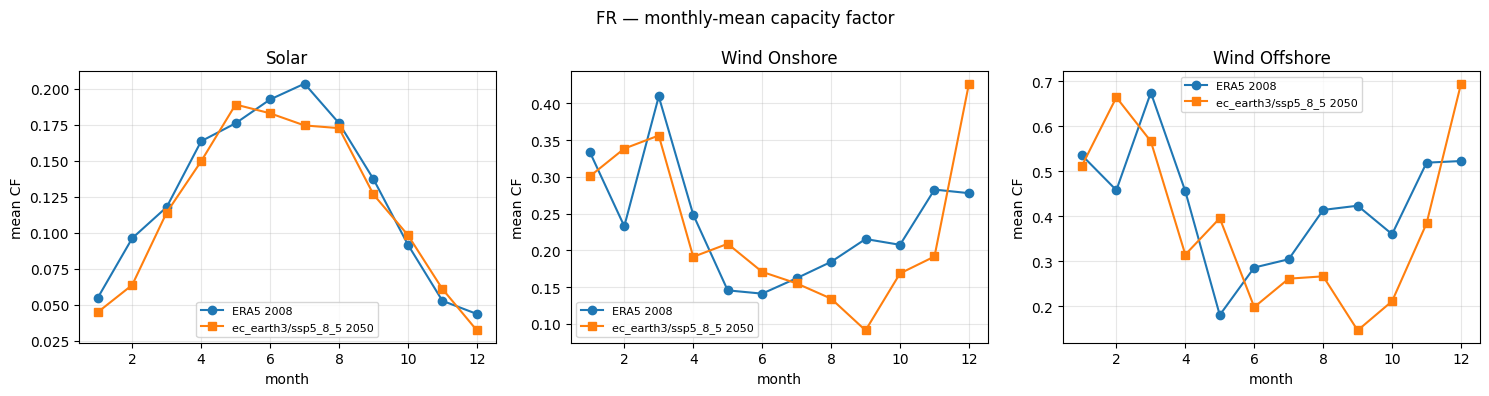

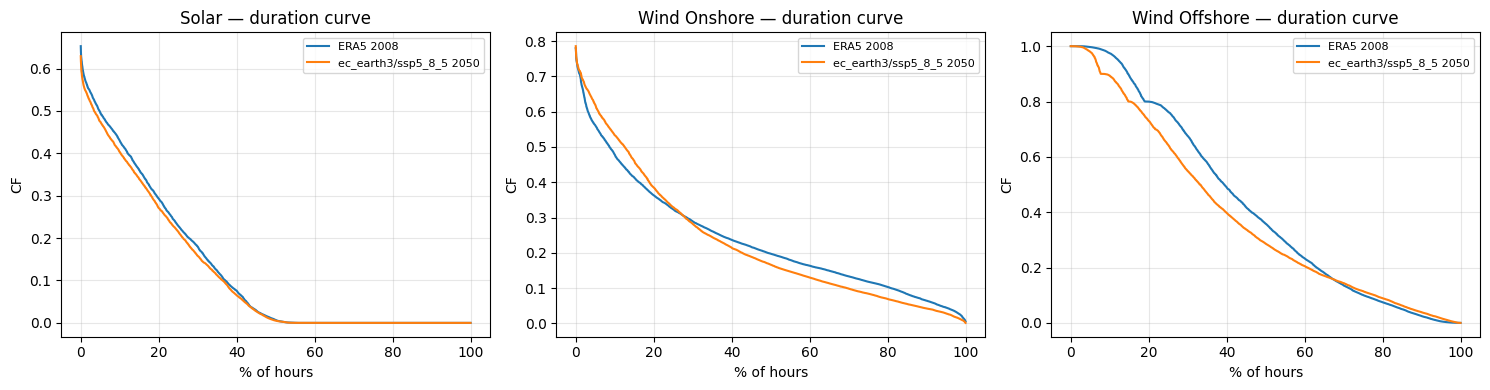

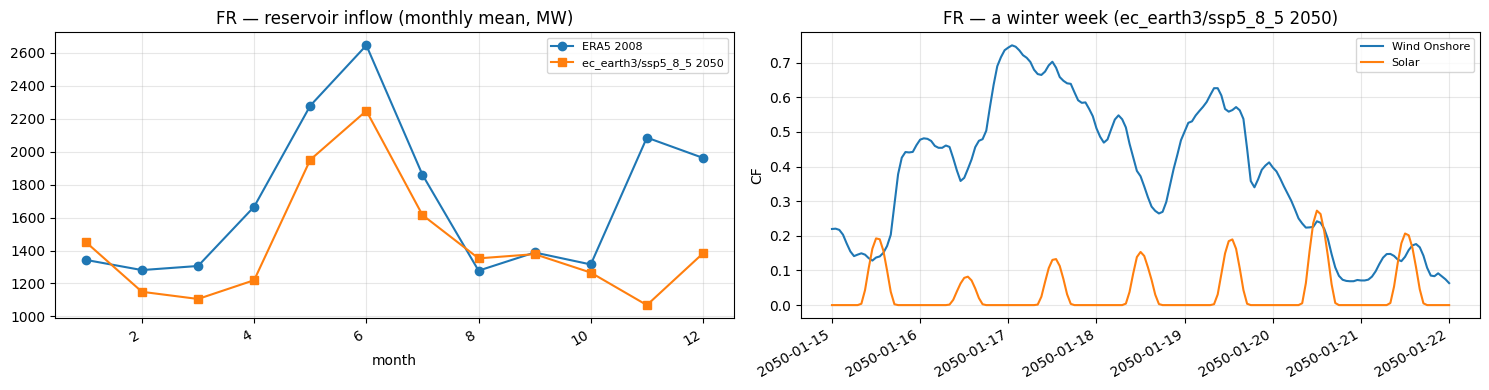

In [6]:
techs = ["Solar", "Wind Onshore", "Wind Offshore"]
monthly = lambda s: s.groupby(s.index.month).mean().reindex(range(1, 13))
proj_lbl = f"{SCENARIO['climate_model']}/{SCENARIO['ssp']} {SCENARIO['year']}"
hist_lbl = f"ERA5 {HISTORICAL_YEAR}"

# 1) Monthly-mean capacity factor (seasonal profile)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, techs):
    if t in hist_cf: ax.plot(range(1, 13), monthly(hist_cf[t]).values, marker="o", label=hist_lbl)
    if t in proj_cf: ax.plot(range(1, 13), monthly(proj_cf[t]).values, marker="s", label=proj_lbl)
    ax.set(title=t, xlabel="month", ylabel="mean CF"); ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.suptitle(f"{cc} — monthly-mean capacity factor"); fig.tight_layout(); plt.show()

# 2) Capacity-factor duration curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, techs):
    for s, lab in [(hist_cf.get(t), hist_lbl), (proj_cf.get(t), proj_lbl)]:
        if s is not None:
            vals = np.sort(s.dropna().values)[::-1]
            ax.plot(np.linspace(0, 100, len(vals)), vals, label=lab)
    ax.set(title=f"{t} — duration curve", xlabel="% of hours", ylabel="CF"); ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

# 3) Reservoir inflow seasonal profile + a representative winter week
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
if hist_inf is not None: ax1.plot(range(1, 13), monthly(hist_inf).values, marker="o", label=hist_lbl)
if proj_inf is not None: ax1.plot(range(1, 13), monthly(proj_inf).values, marker="s", label=proj_lbl)
ax1.set(title=f"{cc} — reservoir inflow (monthly mean, MW)", xlabel="month"); ax1.grid(alpha=.3); ax1.legend(fontsize=8)
if "Wind Onshore" in proj_cf:
    win = slice(pd.Timestamp(f"{SCENARIO['year']}-01-15"), pd.Timestamp(f"{SCENARIO['year']}-01-22"))
    for t in ["Wind Onshore", "Solar"]:
        if t in proj_cf: ax2.plot(proj_cf[t].loc[win].index, proj_cf[t].loc[win].values, label=t)
    ax2.set(title=f"{cc} — a winter week ({proj_lbl})", ylabel="CF"); ax2.grid(alpha=.3); ax2.legend(fontsize=8)
    fig.autofmt_xdate()
fig.tight_layout(); plt.show()

### 5c. Map the climate signal across Europe

The PECD files are **pan-European** — every country's zones live in the same file — so we can
aggregate to a national capacity factor for *all* countries and map it, not just the one in
`SCENARIO`. Below: national **wind-onshore CF** for the historical ERA5 year and the projection,
plus their difference, on a NUTS-0 choropleth. Geometries are fetched once from Eurostat GISCO
via `supplyforge.fetch.tools.visualisation.maps` and cached under `results/geo/` (NUTS ids match
PECD's `nuts_0`/`nuts_2` levels; Greece is `EL`).

> Same caveat as 5b, **amplified across countries**: this is a *single* projection year vs a
> *single* historical year, and the historical (`peon`) and projection (`p2on`) wind-zone systems
> differ — so the Δ panel mixes interannual noise with zone-definition changes and is **not** a
> clean climate signal. For that, average several `climate_years` on both streams. Switch
> `MAP_CODE` to `"SPV"` (solar) or `"WOF"` (offshore) to map other resources.

2026-06-12 15:59:43,191 | INFO | PECD: multiple WON files for 2050: ['pecd42_WON_p2on_2050_ec_earth3_ssp2_4_5_fv1.csv', 'pecd42_WON_p2on_2050_ec_earth3_ssp5_8_5_fv1.csv']; using pecd42_WON_p2on_2050_ec_earth3_ssp2_4_5_fv1.csv.
2026-06-12 15:59:43,637 | INFO | geo: using cached NUTS_RG_20M_2021_4326_LEVL_0.geojson


Wind Onshore: 45 countries (ERA5 2008), 45 (2050)


2026-06-12 15:59:44,068 | INFO | geo: using cached NUTS_RG_20M_2021_4326_LEVL_0.geojson
2026-06-12 15:59:44,286 | INFO | geo: using cached NUTS_RG_20M_2021_4326_LEVL_0.geojson


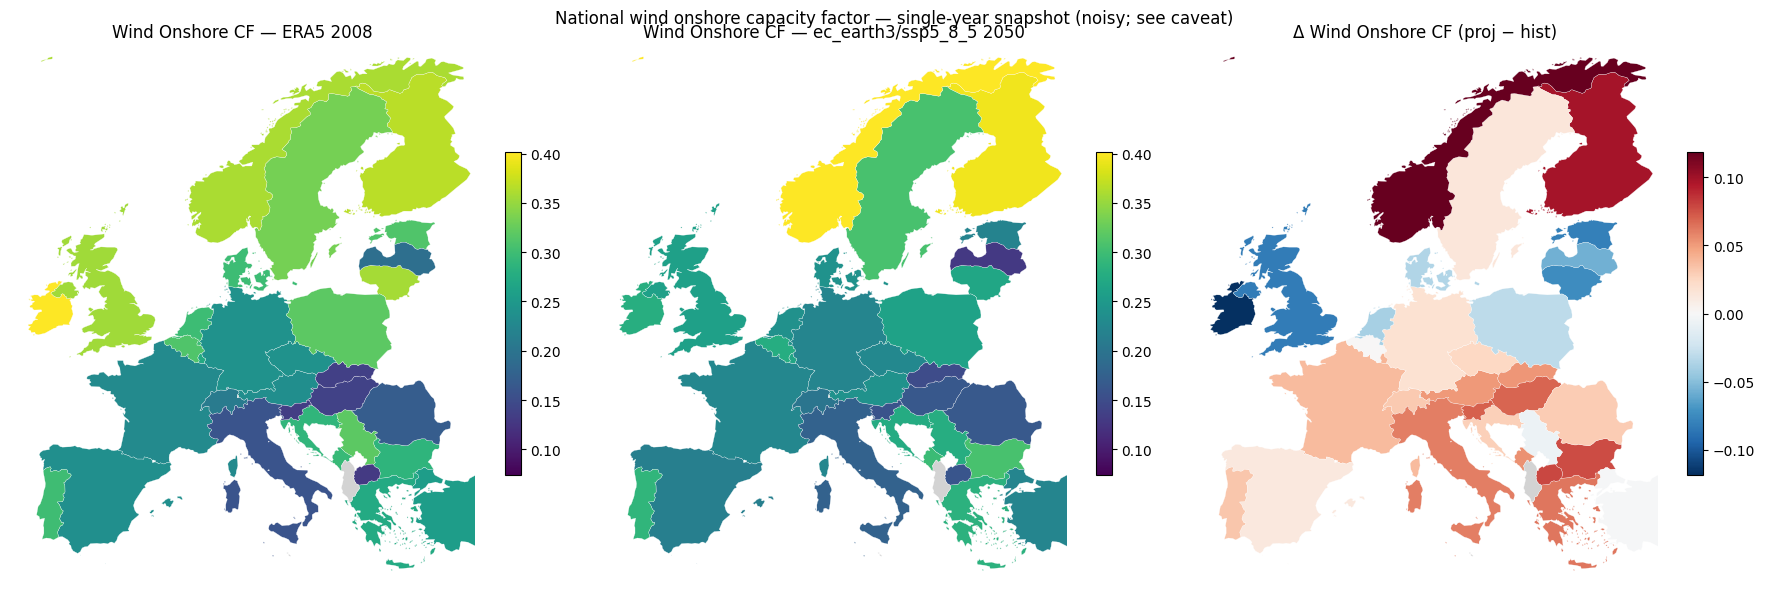

In [7]:
# 5c. National capacity factor across Europe (historical vs projection) on a NUTS-0 map.
import logging
from contextlib import contextmanager
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from supplyforge.process.pecd.capacity_factor import national_cf_from_frame
from supplyforge.process.pecd.hydro_inflow import find_pecd_csv
from supplyforge.fetch.tools.visualisation import maps
from supplyforge.fetch.pecd import zone_registry as zr

MAP_CODE, MAP_LABEL = "WON", "Wind Onshore"        # try "SPV"/"Solar" or "WOF"/"Wind Offshore"
_PECD_TO_NUTS = {"GR": "EL"}                        # PECD area code -> NUTS_ID (else identical)

@contextmanager
def _quiet_supplyforge():                           # mute the per-country equal-weight warnings in the loop
    lg = logging.getLogger("supplyforge"); old = lg.level; lg.setLevel(logging.ERROR)
    try: yield
    finally: lg.setLevel(old)

def national_cf_by_country(code, year):
    """{NUTS_ID: annual-mean national CF} for every registry country present in the file.
    The PECD files are pan-European, so one file yields every country's national CF."""
    path = find_pecd_csv(code, year)
    if path is None:
        return {}
    df = pd.read_csv(path, comment="#", index_col="Date")
    countries = sorted(set(zr.countries("peon")) | set(zr.countries("p2on")) | set(zr.countries("szon")))
    out = {}
    with _quiet_supplyforge():
        for cc in countries:
            try:
                v = national_cf_from_frame(code, cc, df, config)
            except Exception:
                continue
            if v is not None and np.isfinite(np.nanmean(v)) and np.nanmean(v) > 0:
                out[_PECD_TO_NUTS.get(cc, cc)] = float(np.nanmean(v))
    return out

proj_year = SCENARIO["year"]
cf_hist = national_cf_by_country(MAP_CODE, HISTORICAL_YEAR)
cf_proj = national_cf_by_country(MAP_CODE, proj_year)
print(f"{MAP_LABEL}: {len(cf_hist)} countries (ERA5 {HISTORICAL_YEAR}), {len(cf_proj)} ({proj_year})")

allv = list(cf_hist.values()) + list(cf_proj.values())
vmin, vmax = (min(allv), max(allv)) if allv else (0.0, 1.0)
proj_lbl = f"{SCENARIO['climate_model']}/{SCENARIO['ssp']} {proj_year}"

try:  # choropleth needs the optional `geopandas` (pip install supplyforge[viz])
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    maps.choropleth(cf_hist, level=0, ax=axes[0], vmin=vmin, vmax=vmax, cmap="viridis")
    axes[0].set_title(f"{MAP_LABEL} CF — ERA5 {HISTORICAL_YEAR}")
    maps.choropleth(cf_proj, level=0, ax=axes[1], vmin=vmin, vmax=vmax, cmap="viridis")
    axes[1].set_title(f"{MAP_LABEL} CF — {proj_lbl}")
    delta = {k: cf_proj[k] - cf_hist[k] for k in cf_proj if k in cf_hist}
    dmax = max((abs(v) for v in delta.values()), default=0.05) or 0.05
    maps.choropleth(delta, level=0, ax=axes[2], vmin=-dmax, vmax=dmax, cmap="RdBu_r")
    axes[2].set_title(f"Δ {MAP_LABEL} CF (proj − hist)")
    for ax in axes:
        ax.set_xlim(-12, 32); ax.set_ylim(34, 72)          # crop to Europe (drop overseas territories)
    fig.suptitle(f"National {MAP_LABEL.lower()} capacity factor — single-year snapshot (noisy; see caveat)")
    fig.tight_layout(); plt.show()
except RuntimeError as exc:                                 # geopandas missing -> bar-chart fallback
    print(f"(map needs geopandas — `pip install supplyforge[viz]`; bar chart instead: {exc})")
    common = sorted(set(cf_hist) & set(cf_proj), key=lambda k: cf_proj[k])
    x, w = np.arange(len(common)), 0.4
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w / 2, [cf_hist[k] for k in common], w, label=f"ERA5 {HISTORICAL_YEAR}")
    ax.bar(x + w / 2, [cf_proj[k] for k in common], w, label=proj_lbl)
    ax.set_xticks(x); ax.set_xticklabels(common, rotation=90)
    ax.set_ylabel(f"{MAP_LABEL} CF"); ax.legend(); fig.tight_layout(); plt.show()

## 6. Build the small `pommes_craft` model

In [11]:
# --- Build a small pommes_craft dispatch model from the PECD scenario data ------
import numpy as np
import polars as pl
from pommes_craft import (
    EnergyModel, EconomicHypothesis, TimeStepManager, Area,
    ConversionTechnology, StorageTechnology, Demand, LoadShedding, Spillage,
)

def _avail_df(values, hours, year_op):
    v = np.asarray(values, dtype=float)[:8760]
    return pl.DataFrame({"availability": v, "hour": hours, "year_op": [year_op] * 8760})

def build_small_model(country, model_year, cf, inflow_mw, A):
    """A minimal single-area dispatch model: demand met by PECD wind/solar +
    reservoir hydro + a gas backup, with load-shedding/spillage for feasibility.
    `cf` = {plant_type: hourly CF array}, `inflow_mw` = hourly reservoir inflow (MW)."""
    hours = list(range(8760))
    model = EnergyModel(
        name=f"gw_{country}_{model_year}", hours=hours,
        year_ops=[model_year], year_invs=[model_year],
        year_decs=list(range(model_year, model_year + 30, 5)),
        modes=["base"], resources=["electricity", "reservoir_water"],
    )
    with model.context():
        EconomicHypothesis("eco", discount_rate=0.0, year_ref=model_year, planning_step=25)
        TimeStepManager("ts", time_step_duration=1.0, operation_year_duration=8760)
        area = Area(country)

        # Electricity demand (flat profile at the assumed annual energy)
        demand_mw = A["demand_TWh"] * 1e6 / 8760
        area.add_component(Demand(
            name="electricity_demand", resource="electricity",
            demand=pl.DataFrame({"demand": [demand_mw] * 8760, "hour": hours, "year_op": [model_year] * 8760}),
        ))

        # Intermittent renewables: availability = PECD capacity factor, fleet fixed
        for tech, key, label in [("Solar", "solar_GW", "Solar"),
                                 ("Wind_Onshore", "wind_onshore_GW", "Wind Onshore"),
                                 ("Wind_Offshore", "wind_offshore_GW", "Wind Offshore")]:
            cap = A[key] * 1000.0  # GW -> MW
            if cap <= 0 or label not in cf:
                continue
            area.add_component(ConversionTechnology(
                name=tech, factor={"electricity": 1.0},
                availability=_avail_df(cf[label], hours, model_year),
                must_run=0.0, variable_cost=0.0, life_span=25,
                power_capacity_max=cap, power_capacity_min=cap, early_decommissioning=True,
            ))

        # Reservoir hydro from the PECD inflow (store + must-run inflow + dispatchable plant)
        infl = np.asarray(inflow_mw, dtype=float)[:8760]
        if A["hydro_turbine_GW"] > 0 and infl.size and float(np.nanmax(infl)) > 0:
            peak = float(np.nanmax(infl))
            area.add_component(StorageTechnology(
                name="lake_hydro_store",
                factor_in={"reservoir_water": -1.0}, factor_out={"reservoir_water": 1.0},
                factor_keep={"reservoir_water": 0.0}, invest_cost_power=10.0, life_span=25,
                energy_capacity_investment_max=A["hydro_energy_GWh"] * 1000.0,
                energy_capacity_investment_min=A["hydro_energy_GWh"] * 1000.0,
                early_decommissioning=True,
            ))
            area.add_component(ConversionTechnology(
                name="lake_hydro_inflow", factor={"reservoir_water": 1.0},
                availability=_avail_df(infl / peak, hours, model_year), must_run=1.0, life_span=25,
                power_capacity_max=peak, power_capacity_min=peak, early_decommissioning=True,
            ))
            area.add_component(ConversionTechnology(
                name="lake_hydro_plant", factor={"reservoir_water": -1.0, "electricity": 1.0},
                availability=1.0, life_span=25,
                power_capacity_max=A["hydro_turbine_GW"] * 1000.0,
                power_capacity_min=A["hydro_turbine_GW"] * 1000.0, early_decommissioning=True,
            ))

        # Dispatchable gas backup (built up to gas_GW as needed)
        if A["gas_GW"] > 0:
            area.add_component(ConversionTechnology(
                name="Gas", factor={"electricity": 1.0}, availability=1.0, must_run=0.0,
                variable_cost=A["gas_cost"], life_span=25,
                power_capacity_max=A["gas_GW"] * 1000.0, power_capacity_min=0.0, early_decommissioning=True,
            ))

        # Feasibility: load-shedding (expensive) + spillage
        area.add_component(LoadShedding(name="electricity_load_shedding", resource="electricity", cost=30_000.0))
        area.add_component(Spillage(name="electricity_spillage", resource="electricity", max_capacity=1.0e6))
        area.add_component(Spillage(name="reservoir_water_spillage", resource="reservoir_water", max_capacity=5.0e4))
        area.add_component(LoadShedding(name="reservoir_water_load_shedding", resource="reservoir_water", max_capacity=0.0))
    return model

model = build_small_model(SCENARIO["country"], SCENARIO["model_year"], cf, inflow_mw, ASSUMPTIONS)
area = model.areas[SCENARIO["country"]]
print("Model components:", sorted(area.components.keys()))

NameError: name 'cf' is not defined

## 7. Solve and read off the dispatch

`model.run()` solves the 8760-hour linear program (needs an LP solver such as HiGHS);
`get_results()` returns the hourly dispatch, costs and capacities to explore.

In [9]:
# Requires an LP solver — HiGHS via linopy/highspy (`pip install highspy`). Skip for a build-only check.
# return_linopy_model=True hands back the solved linopy model so we can read its status + objective.
linopy_model = model.run(return_linopy_model=True)
print(f"status: {linopy_model.status} / {linopy_model.termination_condition} "
      f"| system cost ≈ €{float(linopy_model.objective.value):,.0f}")

2026-06-07 18:07:25,523 | INFO | Generated table: economichypothesis_year_op.csv with 1 rows and 1 columns


2026-06-07 18:07:25,525 | INFO | Generated table: economichypothesis_.csv with 1 rows and 2 columns


2026-06-07 18:07:25,529 | INFO | Generated table: timestepmanager_hour.csv with 8760 rows and 1 columns


2026-06-07 18:07:25,530 | INFO | Generated table: timestepmanager_year_op.csv with 1 rows and 1 columns


2026-06-07 18:07:25,546 | INFO | Generated table: demand_resource_area_hour_year_op.csv with 8760 rows and 1 columns


...

      40569     1.7189606287e+11 Pr: 0(0); Du: 0(3.47427e-09) 11.1s
      40569     1.7189606287e+11 Pr: 0(0); Du: 0(3.47427e-09) 11.1s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-e6ts01tv
Model status        : Optimal
Simplex   iterations: 40569
Objective value     :  1.7189606287e+11
P-D objective error :  1.8085496734e-12
HiGHS run time      :         11.31


2026-06-07 18:07:42,240 | INFO |  Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 175233 primals, 192758 duals
Objective: 1.72e+11
Solver model: available
Solver message: optimal



Writing the solution to /private/tmp/claude-501/linopy-solve-xx97hav_.sol


2026-06-07 18:07:42,994 | INFO | Model 'gw_FR_2050' solved successfully using solver: highs


status: ok / optimal | system cost ≈ €171,896,062,870


### 7b. Read off the dispatch — annual mix & a sample week

`model.get_results("operation", "power")` returns the solved hourly dispatch (one row per
component-hour). We aggregate it to annual energy by technology and plot a representative week,
where gas + reservoir hydro visibly fill the gaps left by wind and solar. With the default
assumptions the assumed fleet is **slightly short of firm capacity** (a small unserved-energy
tail dominates system cost at the €30,000/MWh value-of-lost-load) — raise `gas_GW`, the
renewable fleet, or `hydro_energy_GWh` in Section 3 to close it.

In [9]:
# 7b. Annual energy mix + a sample week, read from get_results("operation", "power").
import numpy as np, polars as pl, matplotlib.pyplot as plt

power = model.get_results("operation", "power")          # hourly MW, one row per component-hour
series = {}
for n in power["name"].unique().to_list():
    s = power.filter(pl.col("name") == n).sort("hour")["value"].fill_null(0.0).to_numpy()
    if s.size == 8760:
        series[n] = s

ELEC = ["Solar", "Wind_Onshore", "Wind_Offshore", "lake_hydro_plant", "Gas"]   # electricity producers
demand_twh = ASSUMPTIONS["demand_TWh"]
gen = {n: series[n].sum() / 1e6 for n in ELEC if n in series}          # TWh / yr
unserved = max(demand_twh - sum(gen.values()), 0.0)                    # ≈ demand − generation

print(f"{'technology':<16}{'TWh':>8}{'%demand':>9}")
for n, v in sorted(gen.items(), key=lambda kv: -kv[1]):
    print(f"{n:<16}{v:8.1f}{100 * v / demand_twh:8.1f}%")
print(f"{'unserved':<16}{unserved:8.1f}{100 * unserved / demand_twh:8.1f}%")
re_share = sum(gen.get(t, 0) for t in ELEC if t != "Gas") / demand_twh
print(f"\nrenewables+hydro ≈ {re_share:.0%} of demand | gas ≈ {gen.get('Gas', 0) / demand_twh:.0%}"
      f" | system cost ≈ €{float(linopy_model.objective.value):,.0f}"
      f"  (VOLL-dominated: ~{unserved:.1f} TWh unserved × €30,000/MWh)")

# annual mix (left) + a mid-January week's stacked dispatch (right)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 2]})
mix = {**gen, "Unserved": unserved}
axL.bar(range(len(mix)), list(mix.values()))
axL.axhline(demand_twh, ls="--", c="k", lw=1, label="demand")
axL.set_xticks(range(len(mix))); axL.set_xticklabels(list(mix), rotation=45, ha="right")
axL.set(ylabel="TWh / yr", title="Annual electricity mix"); axL.legend(fontsize=8)

order = [n for n in ["Gas", "lake_hydro_plant", "Wind_Offshore", "Wind_Onshore", "Solar"] if n in series]
wk = slice(24 * 14, 24 * 21)              # a mid-January week
demand_mw = demand_twh * 1e6 / 8760
axR.stackplot(range(168), *[series[n][wk] for n in order], labels=order, alpha=0.9)
axR.plot(range(168), [demand_mw] * 168, "k--", lw=1.2, label="demand")
axR.set(title=f"{SCENARIO['country']} {SCENARIO['model_year']} — winter-week dispatch (MW)", xlabel="hour of week")
axR.legend(loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()

NameError: name 'model' is not defined

## 8. Vary the scenario, and the caching plan

**Compare scenarios:** change `SCENARIO["climate_model"]` / `["ssp"]` / `["year"]` (Section 2),
re-run Section 4 (it re-downloads only what's missing), then Sections 5–7. Compare, e.g.,
`ssp1_2_6` vs `ssp5_8_5`, or two climate models, for the same fleet.

**Assumptions:** the fleet/demand in Section 3 are deliberately explicit — they are *your*
scenario, not PECD's. For a realistic future demand *shape* (thermosensitive + EV), generate a
load curve with **demandforge** for the same climate year and replace the flat profile.

**Caching (recommended next step):** the CDS downloads are the slow part. The intended
long-term design is to fetch each `(scenario, year)` set **once**, store the staged CSVs (or
the processed `capacity_factors_*` / `inflow_*` Parquet) in a **Google Cloud bucket**, and have
the first lookup pull from there instead of CDS — exactly how `supplyforge.utils._get_input_data_file`
already serves the ENTSO-E products from `storage.googleapis.com/supplyforge/`. That turns this
notebook's "first run" into a one-time, shared cost.

**Caveats:** offshore/onshore national CF here is equal-weighted over a country's (non-empty)
zones; set `pecd.zone_capacities` for capacity-precise weighting. Reservoir/PHS energy capacity
should come from ERAA `Storage.xlsx` (used as an assumption above).

## 9. Scale up — a multi-country grid (PECD nodes + Ember NTC)

The model above is one country in isolation. `supplyforge.grid_model` scales it to a
**multi-country grid**: each country is a node with its own PECD capacity factors & reservoir
inflow, connected by interconnectors carrying real **Ember net-transfer-capacities (NTC)**. A
pommes `Link` is one-way, so each border becomes two opposing links capped at the NTC.

> PECD provides the nodes + per-zone weather; it ships **no** grid topology/NTC, so the
> interconnections come from supplyforge's Ember NTC module (country-level). For finer PECD SZON
> bidding-zone nodes, supply ERAA/PEMMDB zone-level NTCs — `build_grid_model` takes any nodes + links.
>
> Solving N countries × 8760 h is ~N× the single-node LP (the 4 countries below ≈ 2 min on HiGHS).

In [11]:
# Build + solve a small European grid: country nodes + Ember NTC links, all PECD-driven.
from supplyforge.grid_model import build_european_grid, ember_ntc_links, grid_flows

GRID_COUNTRIES = ["FR", "DE", "BE", "CH"]          # add NL, ES, IT, AT… (each ~+30 s solve)

# Per-country launch assumptions (illustrative 2050 fleets; GW / TWh / GWh) — edit freely.
GRID_ASSUMPTIONS = {
    "FR": dict(solar_GW=100, wind_onshore_GW=70,  wind_offshore_GW=30, hydro_turbine_GW=20, hydro_energy_GWh=30000, gas_GW=40, gas_cost=80, demand_TWh=480),
    "DE": dict(solar_GW=150, wind_onshore_GW=120, wind_offshore_GW=50, hydro_turbine_GW=5,  hydro_energy_GWh=3000,  gas_GW=60, gas_cost=80, demand_TWh=550),
    "BE": dict(solar_GW=15,  wind_onshore_GW=6,   wind_offshore_GW=8,  hydro_turbine_GW=0,  hydro_energy_GWh=0,     gas_GW=12, gas_cost=80, demand_TWh=90),
    "CH": dict(solar_GW=12,  wind_onshore_GW=1,   wind_offshore_GW=0,  hydro_turbine_GW=15, hydro_energy_GWh=8000,  gas_GW=2,  gas_cost=80, demand_TWh=65),
}

print("Ember NTC links (MW):", ember_ntc_links(GRID_COUNTRIES))
grid = build_european_grid(GRID_COUNTRIES, SCENARIO["year"], SCENARIO["model_year"], GRID_ASSUMPTIONS, config)
print(f"grid: {len(grid.areas)} nodes, {len(grid.links)} one-way links — solving (~2 min on HiGHS)…")
grid_lm = grid.run(return_linopy_model=True)
print(f"status {grid_lm.status} / {grid_lm.termination_condition} | system cost ≈ €{float(grid_lm.objective.value):,.0f}")

2026-06-07 18:07:43,243 | INFO | Ember NTC: 5 intra-set links among 4 countries


2026-06-07 18:07:43,244 | INFO | PECD: multiple SPV files for 2050: ['pecd42_SPV_nuts_2_2050_ec_earth3_ssp5_8_5_fv1.csv', 'pecd42_SPV_szon_2050_ec_earth3_ssp5_8_5_fv1.csv']; using pecd42_SPV_nuts_2_2050_ec_earth3_ssp5_8_5_fv1.csv.


Ember NTC links (MW): [('BE', 'FR', 5300.0), ('CH', 'FR', 4500.0), ('DE', 'FR', 4800.0), ('BE', 'DE', 1000.0), ('CH', 'DE', 5000.0)]


2026-06-07 18:07:43,582 | INFO | PECD: country 'FR' -> zones ['FR10', 'FRB0', 'FRC1', 'FRC2', 'FRD1', 'FRD2', 'FRE1', 'FRE2', 'FRF1', 'FRF2', 'FRF3', 'FRG0', 'FRH0', 'FRI1', 'FRI2', 'FRI3', 'FRJ1', 'FRJ2', 'FRK1', 'FRK2', 'FRL0', 'FRM0']


2026-06-07 18:07:43,583 | WARNING | PECD weights: no per-zone installed capacities configured for solar; multi-zone aggregation will use EQUAL weights (less precise). Set pecd.zone_capacities or pecd.zone_capacities_csv for precise weighting. Run write_capacity_template(country, level, path) to emit a per-zone CSV skeleton (from the zone registry), fill it with installed MW from your PEMMDB/ERAA scenario, and point pecd.zone_capacities_csv at it.


...


Model name          : linopy-problem-n5bc49c_
Model status        : Optimal
Simplex   iterations: 132558
Objective value     :  3.1913785380e+10
P-D objective error :  2.9799160989e-13
HiGHS run time      :         41.91


Writing the solution to /private/tmp/claude-501/linopy-solve-prn5li22.sol


2026-06-07 18:09:32,297 | INFO |  Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2619775 primals, 2751187 duals
Objective: 3.19e+10
Solver model: available
Solver message: optimal



2026-06-07 18:09:37,308 | INFO | Model 'grid_FR_DE_BE_CH_2050' solved successfully using solver: highs


status ok / optimal | system cost ≈ €31,913,785,380


2026-06-07 18:09:37,401 | INFO | geo: using cached NUTS_RG_20M_2021_4326_LEVL_0.geojson


generation (TWh): {'FR': 478.8, 'DE': 573.2, 'BE': 86.8, 'CH': 46.2}
net imports (TWh, + import / - export): {'FR': 1.2, 'DE': -23.2, 'BE': 3.2, 'CH': 18.8}


2026-06-07 18:09:37,670 | INFO | geo: using cached NUTS_RG_20M_2021_4326_LEVL_0.geojson


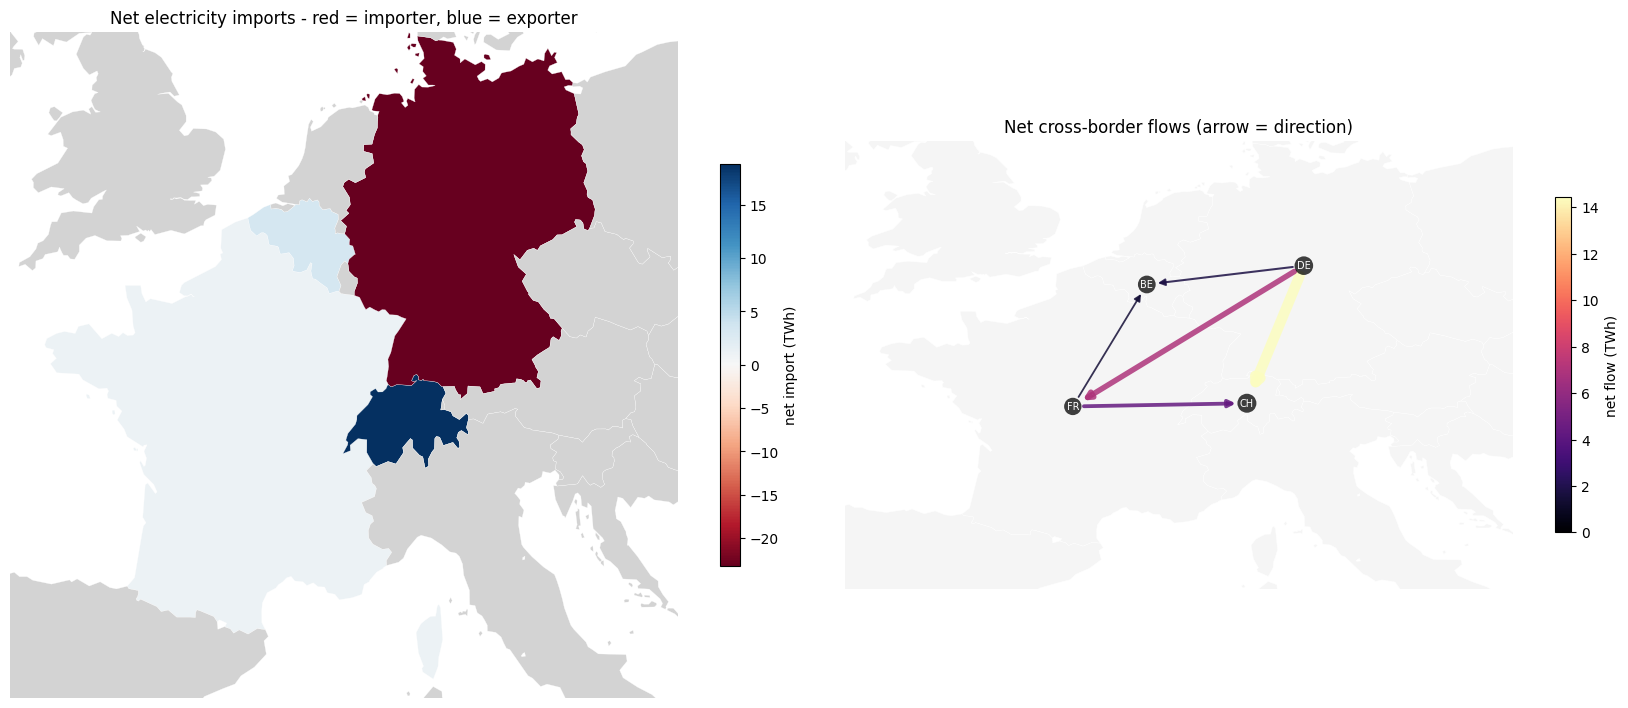

In [12]:
# Read off the grid: per-country generation, net imports, and cross-border flows.
import numpy as np, polars as pl, matplotlib.pyplot as plt
from supplyforge.fetch.tools.visualisation import maps

power = grid.get_results("operation", "power")
ct = power.filter(pl.col("component_class") == "ConversionTechnology")
gen = {r["area"]: r["TWh"] for r in
       ct.filter(~pl.col("name").str.ends_with("_lake_inflow"))
         .group_by("area").agg((pl.col("value").sum() / 1e6).alias("TWh")).iter_rows(named=True)}
twh = {r["name"]: r["TWh"] for r in
       grid_flows(grid).group_by("name").agg((pl.col("value").sum() / 1e6).alias("TWh")).iter_rows(named=True)}

net_import = {}
for c in GRID_COUNTRIES:
    imp = sum(v for n, v in twh.items() if n.endswith(f"_{c}"))        # links "*->c" (imports to c)
    exp = sum(v for n, v in twh.items() if n.startswith(f"NTC_{c}_"))  # links "c->*" (exports from c)
    net_import[c] = imp - exp
borders = sorted({tuple(sorted((n.split("_")[1], n.split("_")[2]))) for n in twh})
net_flow = {(a, b): twh.get(f"NTC_{a}_{b}", 0) - twh.get(f"NTC_{b}_{a}", 0) for a, b in borders}
print("generation (TWh):", {c: round(gen.get(c, 0), 1) for c in GRID_COUNTRIES})
print("net imports (TWh, + import / - export):", {c: round(v, 1) for c, v in net_import.items()})

# left: net imports per country (diverging at 0); right: directed flow arrows (maps.flow_map)
_to_nuts = {"GR": "EL"}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(17, 7))
maps.choropleth({_to_nuts.get(c, c): v for c, v in net_import.items()}, level=0, ax=axL,
                region="cwe", vcenter=0.0, cmap="RdBu", cbar_label="net import (TWh)",
                title="Net electricity imports - red = importer, blue = exporter")
maps.flow_map({(_to_nuts.get(a, a), _to_nuts.get(b, b)): v for (a, b), v in net_flow.items()},
              level=0, ax=axR, region="cwe", cmap="magma", cbar_label="net flow (TWh)",
              title="Net cross-border flows (arrow = direction)")
fig.tight_layout(); plt.show()

## 10. Regional resolution - solar capacity factor by NUTS-2 region

How fine can we go *thanks to these databases*? **Solar** is available from PECD at **NUTS-2
(regions)**, so we can map it sub-nationally. Below: across Europe, and zoomed into France - where
the **north->south solar gradient** is clear (Ile-de-France `FR10` ~0.11 -> Provence `FRL0` ~0.14
-> Corsica `FRM0` ~0.15). Wind/hydro stay on PECD's bidding/wind zones; **departments (NUTS-3)**
are *not* in PECD's aggregated products - they'd need the Phase-2 raw-ERA5 + `atlite` engine.
(PECD's `nuts_2` set also includes non-EU/MENA regions for interconnection studies; only the
European NUTS-2 match GISCO geometry and appear on the map.)

2026-06-07 18:09:37,951 | INFO | PECD: fetching codes ['SPV', 'WON', 'WOF'] for climate years [2050]


2026-06-07 18:09:38,428 | INFO | PECD: pecd42_SPV_nuts_2_2050_ec_earth3_ssp5_8_5_fv1.csv already staged, skipping.


2026-06-07 18:09:38,429 | INFO | PECD: pecd42_WON_p2on_2050_ec_earth3_ssp5_8_5_fv1.csv already staged, skipping.


2026-06-07 18:09:38,432 | INFO | PECD: pecd42_WOF_p2of_2050_ec_earth3_ssp5_8_5_fv1.csv already staged, skipping.


2026-06-07 18:09:38,433 | INFO | PECD: staged 3 file(s) under /Users/simonbrigode/paper_projects/supplyforge_PECD/results/pecd_study


/tmp/claude-501/ipykernel_67821/1947486690.py:13: RuntimeWarning: Mean of empty slice
  cf_nuts2 = {c: float(np.nanmean(pd.to_numeric(df[c], errors="coerce").to_numpy())) for c in df.columns}
2026-06-07 18:09:38,889 | INFO | geo: using cached NUTS_RG_10M_2021_4326_LEVL_2.geojson


616 NUTS-2 regions in PECD; France solar CF 0.101-0.149


2026-06-07 18:09:39,129 | INFO | geo: using cached NUTS_RG_10M_2021_4326_LEVL_2.geojson


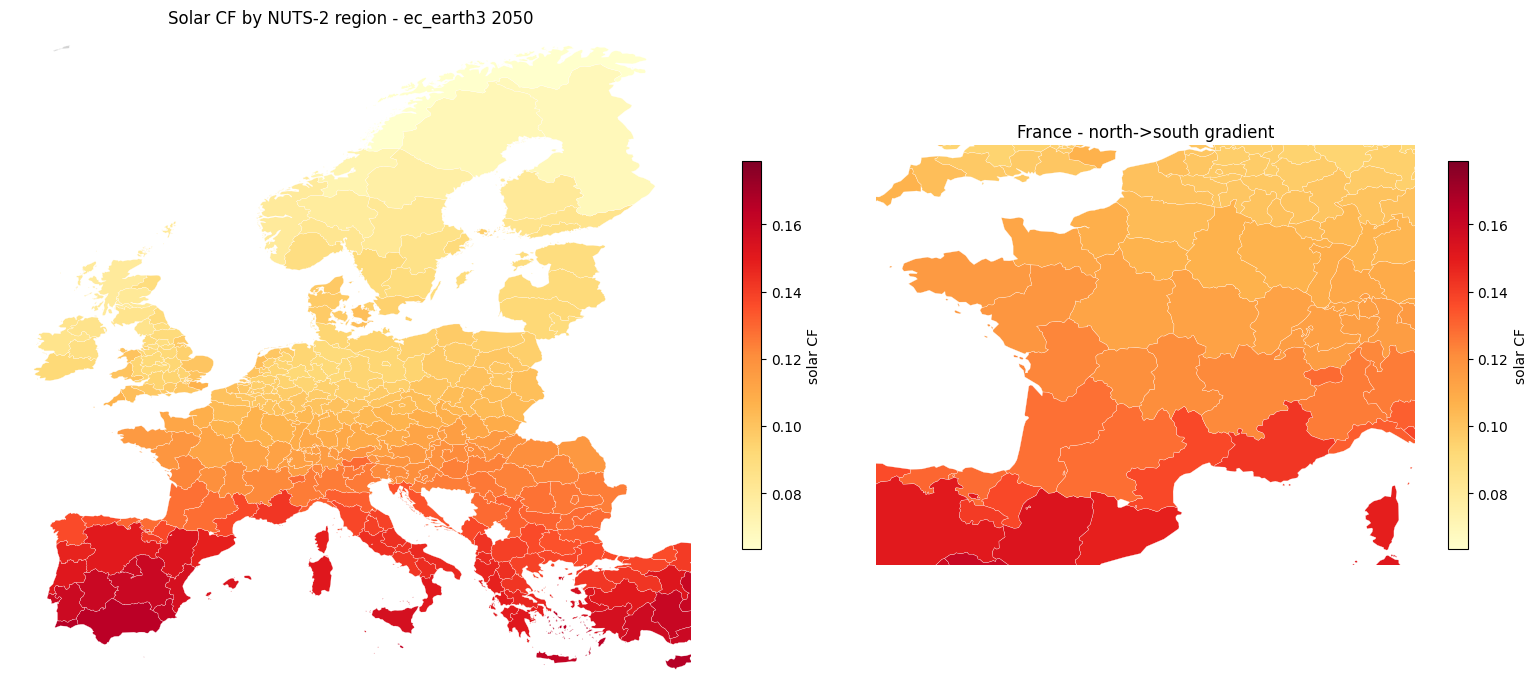

In [13]:
# Solar CF at NUTS-2 - fetch (cached after first run) + regional choropleth via the maps tool.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from supplyforge import RESULTS_DIR
from supplyforge.fetch.pecd.study import fetch_pecd_data
from supplyforge.fetch.tools.visualisation import maps

nuts2_cfg = {**config, "hydro_source": "entsoe",
             "pecd": {**config["pecd"], "spatial_resolution_solar": "nuts_2"}}
fetch_pecd_data(nuts2_cfg)   # first run ~8 min on CDS; cached afterwards

p = sorted((RESULTS_DIR / "pecd_study").glob(f"pecd42_SPV_nuts_2_{SCENARIO['year']}*.csv"))[0]
df = pd.read_csv(p, comment="#", index_col="Date")
cf_nuts2 = {c: float(np.nanmean(pd.to_numeric(df[c], errors="coerce").to_numpy())) for c in df.columns}
cf_nuts2 = {k: v for k, v in cf_nuts2.items() if np.isfinite(v) and v > 0}
fr = {k: v for k, v in cf_nuts2.items() if k.startswith("FR")}
print(f"{len(cf_nuts2)} NUTS-2 regions in PECD; France solar CF {min(fr.values()):.3f}-{max(fr.values()):.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={"width_ratios": [1.5, 1]})
maps.choropleth(cf_nuts2, level=2, scale="10M", ax=a1, region="europe", cmap="YlOrRd",
                cbar_label="solar CF", title=f"Solar CF by NUTS-2 region - {SCENARIO['climate_model']} {SCENARIO['year']}")
maps.choropleth(cf_nuts2, level=2, scale="10M", ax=a2, region="france", cmap="YlOrRd",
                cbar_label="solar CF", title="France - north->south gradient")
fig.tight_layout(); plt.show()

## 11. Real installed capacity from OpenStreetMap

PECD gives *capacity factors* — it doesn't say how many GW are actually installed, or where. The new
`supplyforge.fetch.osm` module fills that gap from **OpenStreetMap** `power=plant` features: real,
georeferenced power stations tagged with `plant:source` (fuel) and `plant:output:electricity` (rating).

A single **cached** Overpass query (mirror rotation + back-off + on-disk cache — the public API
throttles bursts hard) returns every plant in a bounding box; `plants_to_region_capacity` parses each
rating to MW and aggregates by **point-in-NUTS-2**, giving real installed capacity per region per
technology. *(OSM is ODbL — © OpenStreetMap contributors.)*

Below: metropolitan France. The by-tech totals track reality (hydro ≈25 GW, onshore wind ≈24 GW,
nuclear ≈48 GW). Rooftop **solar is under-mapped**, so its ≈11 GW is a lower bound — a known caveat
(`plant:output:electricity` is often `yes`/absent, so those plants are counted but add no MW). These
per-region fleets feed the regional model in §12.

2026-06-07 18:09:39,648 | INFO | OSM Overpass: using cached plants_fr_metro.json


2026-06-07 18:09:39,735 | INFO | OSM plants: 12797 found, 7580 with MW (59%), 296091 MW total.


2026-06-07 18:09:39,779 | INFO | geo: using cached NUTS_RG_20M_2021_4326_LEVL_2.geojson


2026-06-07 18:09:39,865 | INFO | OSM: aggregated 7494 plants into 92 NUTS-2 regions.


2026-06-07 18:09:39,877 | INFO | geo: using cached NUTS_RG_10M_2021_4326_LEVL_2.geojson


12797 OSM plants; France installed capacity by tech (GW): {'nuclear': 48.2, 'hydro': 24.9, 'wind_onshore': 23.8, 'solar': 11.0, 'gas': 7.4, 'oil': 2.4, 'coal': 1.9, 'biomass': 0.9, 'waste': 0.9, 'battery': 0.8, 'tidal': 0.2, 'geothermal': 0.0, 'other': 0.0}


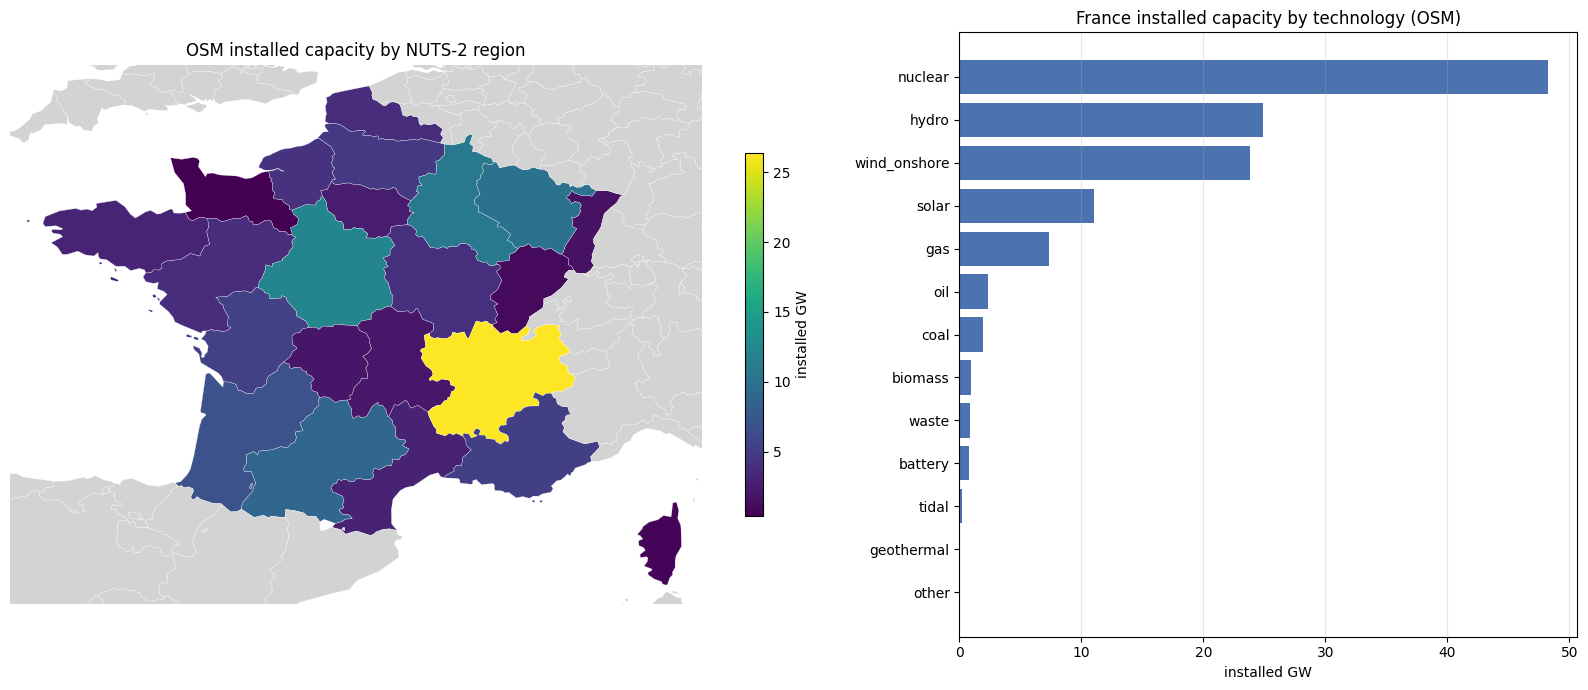

In [14]:
# OSM power=plant -> real installed capacity per NUTS-2 region, by technology.
from collections import Counter
import matplotlib.pyplot as plt
from supplyforge.fetch.osm.generation import fetch_power_plants, plants_to_region_capacity
from supplyforge.fetch.tools.visualisation import maps

# One cached Overpass call for metropolitan France (served from results/osm/ after the first run).
plants = fetch_power_plants((41, -5.5, 51.5, 10), cache_key="plants_fr_metro")
cap = plants_to_region_capacity(plants, level=2)                 # {NUTS-2: {tech: MW}}
fr = {r: d for r, d in cap.items() if str(r).startswith("FR")}
total_gw = {r: sum(d.values()) / 1000 for r, d in fr.items()}   # installed GW per region
by_tech = Counter()
for d in fr.values():
    for t, mw in d.items():
        by_tech[t] += mw / 1000
print(f"{len(plants)} OSM plants; France installed capacity by tech (GW):",
      {t: round(v, 1) for t, v in by_tech.most_common()})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.4, 1]})
maps.choropleth(total_gw, level=2, scale="10M", ax=axL, region="france", cmap="viridis",
                cbar_label="installed GW", title="OSM installed capacity by NUTS-2 region")
techs = [t for t, _ in by_tech.most_common()]
axR.barh(techs[::-1], [by_tech[t] for t in techs[::-1]], color="#4C72B0")
axR.set(xlabel="installed GW", title="France installed capacity by technology (OSM)")
axR.grid(alpha=.3, axis="x")
fig.tight_layout(); plt.show()

## 12. Regional dispatch on real capacities (OSM-fed)

Putting the pieces together: `scripts/regional_fr_de_be.py --capacities=osm` builds a **NUTS-2
regional** `pommes_craft` model where every region's fleet is the **real OSM capacity** from §11
(solar & wind direct; the dispatchable fleet — nuclear, gas, … — lumped as firm capacity), driven by
regional **solar CF** from PECD `nuts_2`, with **transport links** between adjacent regions
(cross-border links carry the Ember country NTC). Demand is split across each country's regions by
area (OSM carries no demand).

For France in January (**22 regions × 744 h**, all 22 fleets populated from OSM) it solves in ~10 min,
and the dispatch redistributes power from the **nuclear- and hydro-rich** regions toward the load
centres. The map below — produced by the script (too heavy to solve inline) — shows the resulting
**net regional electricity flows**:

![Net regional electricity flows — France, January, OSM-derived capacities](figures/regional_fr_osm_flows.png)

*(Each firm technology is dispatched in **merit order** by short-run marginal cost — nuclear ≈€12/MWh
and hydro ≈€8 ahead of gas ≈€80 and oil ≈€150 — so the cheap nuclear+hydro fleet carries the load and
the January system cost is **≈€63 M**. Hydro is modelled as cheap firm without a per-region energy
limit, a known simplification.)*

In [15]:
# Reproduce the figure above (~5 min on a laptop). Cross-border FR+DE+BE: drop --countries, add --month.
# Kept commented so "Run all" stays fast — uncomment to run.
# !python ../scripts/regional_fr_de_be.py --countries=FR --month=1 --capacities=osm --solve

## 13. The supply network & industrial demand from OpenStreetMap

§11 mapped power *plants*. The same `supplyforge.fetch.osm` package also captures the **grid that carries
the power** and the **industry that consumes it**, via the cached Overpass client + point-in-NUTS:

- **`electricity.py`** — `power=substation` (`transmission_only=True` → France's ~2,700-node grid
  backbone, excluding small MV/LV distribution substations) and HVDC `power=converter` stations.
- **`electricity_lines.py`** — `power=line`/`cable` → voltage, circuits and geodesic length → circuit-km
  by voltage class (EHV/HV).
- **`industry.py`** — `landuse=industrial` + `man_made=works` → industrial sites & land area, a
  sub-national **electricity-demand proxy** where no metered data exists.

Left: France's transmission-substation density by NUTS-2 — densest in the nuclear/hydro-rich southeast
(Auvergne-Rhône-Alpes, 161) and the load centres. Right: the line + industry modules at regional scale
(Île-de-France & neighbours). **Country-scale `landuse` / `out geom` queries time out on the busy public
Overpass mirrors, so for nationwide line circuit-km or industrial area use a
[Geofabrik](https://download.geofabrik.de) extract** — the modules accept any bbox; the bottleneck is the
public API, not the code. *(OSM is ODbL — © OpenStreetMap contributors.)*

2026-06-07 18:09:40,341 | INFO | OSM Overpass: using cached subs_fr_tx.json


2026-06-07 18:09:40,362 | INFO | OSM substations: 2687 (2484 with voltage).


2026-06-07 18:09:40,381 | INFO | geo: using cached NUTS_RG_20M_2021_4326_LEVL_2.geojson


2026-06-07 18:09:40,458 | INFO | OSM: 2644 substations -> 90 NUTS-2 regions.


2026-06-07 18:09:40,460 | INFO | OSM Overpass: using cached idf_lines_ctr.json


...

2026-06-07 18:09:40,637 | INFO | OSM industrial sites: 3067 (0 with geometry).


2026-06-07 18:09:40,655 | INFO | geo: using cached NUTS_RG_20M_2021_4326_LEVL_2.geojson


2026-06-07 18:09:40,702 | INFO | OSM: 3067 industrial sites -> 6 NUTS-2 regions (0 km2 total).


2026-06-07 18:09:40,713 | INFO | geo: using cached NUTS_RG_10M_2021_4326_LEVL_2.geojson


France: 2687 transmission substations (22 NUTS-2 regions) | Île-de-France sample: 5439 lines, 3067 industrial sites


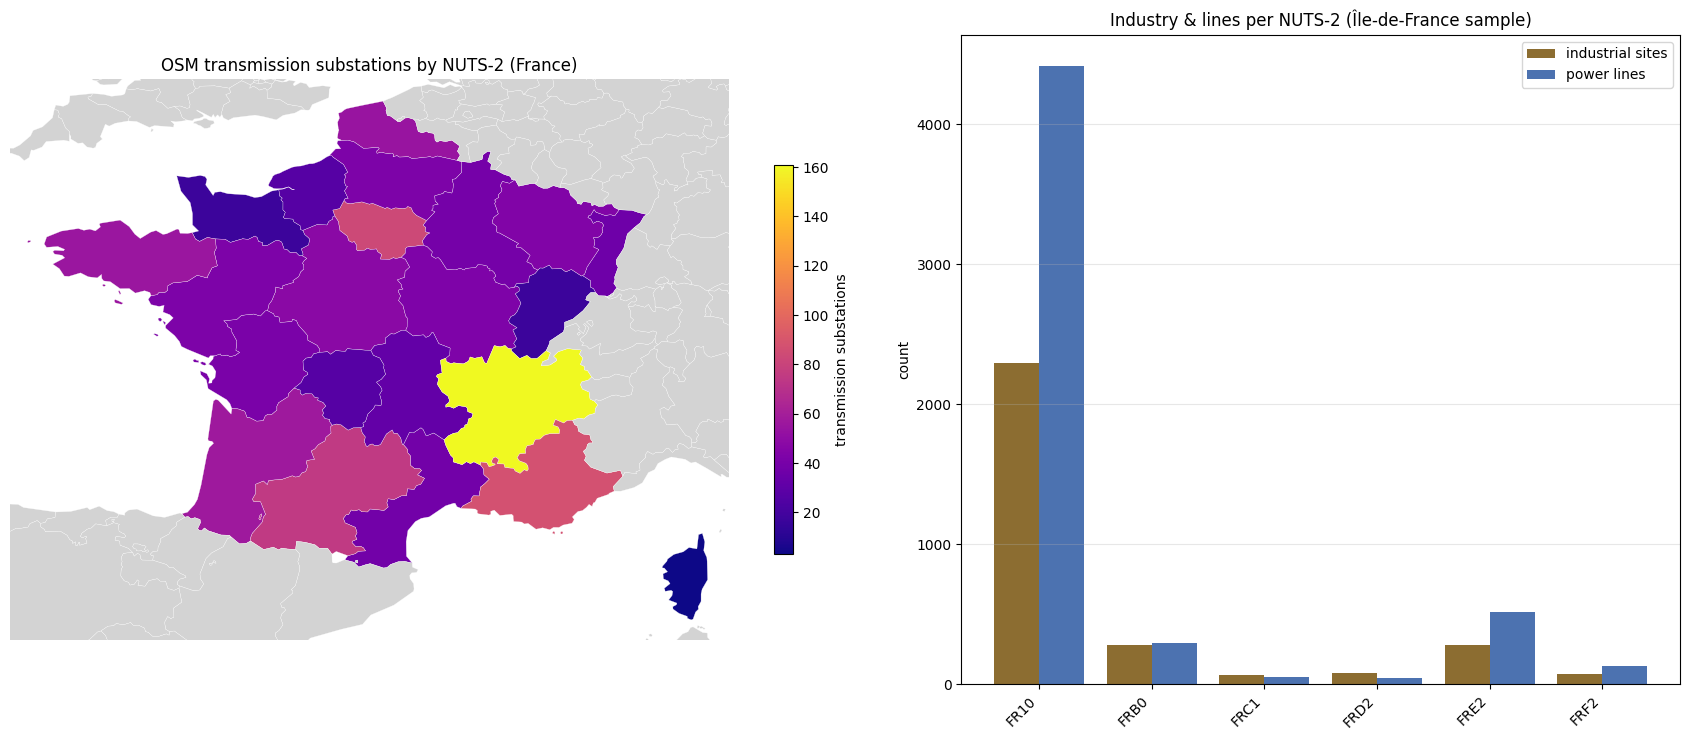

In [16]:
# 13. OSM grid backbone (substations) + industry & lines per region — the network around the plants.
import numpy as np, matplotlib.pyplot as plt
from supplyforge.fetch.osm import electricity as osm_elec, electricity_lines as osm_lines, industry as osm_ind
from supplyforge.fetch.tools.visualisation import maps

FR_BB, IDF_BB = (41, -5.5, 51.5, 10), (48.1, 1.4, 49.3, 3.6)
# France grid backbone: transmission substations per NUTS-2 (cached after first fetch).
subs = osm_elec.fetch_substations(FR_BB, transmission_only=True, cache_key="subs_fr_tx")
sub_reg = {r: v["n"] for r, v in osm_elec.substations_to_region(subs).items() if str(r).startswith("FR")}
# Lines + industry at Île-de-France scale (country-wide out-geom / landuse times out on public Overpass).
lines = osm_lines.fetch_power_lines(IDF_BB, geometry=False, cache_key="idf_lines_ctr")
line_reg = {r: v["n_lines"] for r, v in osm_lines.lines_to_region_stats(lines).items()}
sites = osm_ind.fetch_industrial_sites(IDF_BB, with_area=False, cache_key="idf_ind_ctr")
ind_reg = {r: v["n_sites"] for r, v in osm_ind.sites_to_region(sites).items()}
print(f"France: {len(subs)} transmission substations ({len(sub_reg)} NUTS-2 regions) | "
      f"Île-de-France sample: {len(lines)} lines, {len(sites)} industrial sites")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(17, 7.5), gridspec_kw={"width_ratios": [1.25, 1]})
maps.choropleth(sub_reg, level=2, scale="10M", ax=axL, region="france", cmap="plasma",
                cbar_label="transmission substations", title="OSM transmission substations by NUTS-2 (France)")
regs = sorted(set(line_reg) | set(ind_reg))
x = np.arange(len(regs)); w = 0.4
axR.bar(x - w / 2, [ind_reg.get(r, 0) for r in regs], w, label="industrial sites", color="#8C6D31")
axR.bar(x + w / 2, [line_reg.get(r, 0) for r in regs], w, label="power lines", color="#4C72B0")
axR.set_xticks(x); axR.set_xticklabels(regs, rotation=45, ha="right")
axR.set(ylabel="count", title="Industry & lines per NUTS-2 (Île-de-France sample)")
axR.legend(); axR.grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()